Regresión Binomial negativa, el modelo adecuado para datos de conteo con sobredispersión

In [18]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy import stats
import duckdb

# preprocesar datos para el modelo

In [19]:
empresas_df = pd.read_parquet('../data/silver/iberinform_startups_certificadas.parquet')
empresas_df['anno_constitucion'] = pd.to_datetime(empresas_df['fecha_constitucion'], errors='coerce').dt.year

def get_empresas_provinciales(anno, empresas_df, operator='=='):
    return duckdb.query(
        f"""
        PIVOT (
        -- 1. Preparamos los datos filtrados y calculamos el total por provincia
        SELECT 
            cpro,
            grupo_cnae,
            COUNT(*) OVER (PARTITION BY provincia) AS startups
        FROM empresas_df 
        WHERE anno_constitucion {operator} {anno}
    ) 
    -- 2. Definimos que los nombres de las columnas serán los grupos CNAE
    ON grupo_cnae 

    -- 3. La métrica a contar es el número de startups por cada cruce
    USING COUNT(*) 

    -- 4. Agrupamos por provincia y mantenemos el total que calculamos antes
    GROUP BY 
        cpro,
        startups
    ORDER BY 
        startups DESC;
        """).to_df().sort_values('cpro').reset_index(drop=True).rename(columns={
            '72': 'startups_I_mas_D',
            '62': 'startups_IT',
        })

nuevas_empresas_provinciales_2024 = get_empresas_provinciales(2024, empresas_df)
nuevas_empresas_provinciales_2023 = get_empresas_provinciales(2023, empresas_df)
nuevas_empresas_provinciales_2022 = get_empresas_provinciales(2022, empresas_df)
nuevas_empresas_provinciales_2021 = get_empresas_provinciales(2021, empresas_df)
nuevas_empresas_accumuladas_2024 = get_empresas_provinciales('2021 AND 2024', empresas_df, operator='BETWEEN')


In [20]:
poblacion_2024_df = pd.read_parquet('../data/silver/poblacion_2024.parquet')
poblacion_2023_df = pd.read_parquet('../data/silver/poblacion_2023.parquet')
poblacion_2022_df = pd.read_parquet('../data/silver/poblacion_2022.parquet')
poblacion_2021_df = pd.read_parquet('../data/silver/poblacion_2021.parquet')
poblacion_2020_df = pd.read_parquet('../data/silver/poblacion_2020.parquet')
poblacion_provincial_2024 = poblacion_2024_df.groupby('cpro')['poblacion'].sum().reset_index()
poblacion_provincial_2023 = poblacion_2023_df.groupby('cpro')['poblacion'].sum().reset_index()
poblacion_provincial_2022 = poblacion_2022_df.groupby('cpro')['poblacion'].sum().reset_index()
poblacion_provincial_2021 = poblacion_2021_df.groupby('cpro')['poblacion'].sum().reset_index()
poblacion_provincial_2020 = poblacion_2020_df.groupby('cpro')['poblacion'].sum().reset_index()
poblacion_provincial_2024['variacion'] = poblacion_provincial_2024['poblacion'] - poblacion_provincial_2023['poblacion']
poblacion_provincial_2024['pct_variacion'] = (poblacion_provincial_2024['poblacion'] - poblacion_provincial_2023['poblacion']) / poblacion_provincial_2023['poblacion']
poblacion_provincial_2023['variacion'] = poblacion_provincial_2023['poblacion'] - poblacion_provincial_2022['poblacion']
poblacion_provincial_2023['pct_variacion'] = (poblacion_provincial_2023['poblacion'] - poblacion_provincial_2022['poblacion']) / poblacion_provincial_2022['poblacion']
poblacion_provincial_2022['variacion'] = poblacion_provincial_2022['poblacion'] - poblacion_provincial_2021['poblacion']
poblacion_provincial_2022['pct_variacion'] = (poblacion_provincial_2022['poblacion'] - poblacion_provincial_2021['poblacion']) / poblacion_provincial_2021['poblacion']
poblacion_provincial_2021['variacion'] = poblacion_provincial_2021['poblacion'] - poblacion_provincial_2020['poblacion']
poblacion_provincial_2021['pct_variacion'] = (poblacion_provincial_2021['poblacion'] - poblacion_provincial_2020['poblacion']) / poblacion_provincial_2020['poblacion']

In [21]:
cobertura_df = pd.read_csv('../data/gold/cobertura_provincial.csv',sep=';', dtype={'cpro': str})
cobertura_2021_df = cobertura_df[cobertura_df['anno'] == 2021].copy().reset_index(drop=True)
cobertura_2022_df = cobertura_df[cobertura_df['anno'] == 2022].copy().reset_index(drop=True)
cobertura_2023_df = cobertura_df[cobertura_df['anno'] == 2023].copy().reset_index(drop=True)
cobertura_2024_df = cobertura_df[cobertura_df['anno'] == 2024].copy().reset_index(drop=True)

In [22]:
afiliados_df = pd.read_csv('../data/gold/afiliados_provincial.csv',sep=';', dtype={'cpro': str})
afiliados_2021_df = afiliados_df.query('anno == 2021').copy().reset_index(drop=True)
afiliados_2022_df = afiliados_df.query('anno == 2022').copy().reset_index(drop=True)
afiliados_2023_df = afiliados_df.query('anno == 2023').copy().reset_index(drop=True)
afiliados_2024_df = afiliados_df.query('anno == 2024').copy().reset_index(drop=True)
for df in [afiliados_2021_df, afiliados_2022_df, afiliados_2023_df, afiliados_2024_df]:
    df['pct_afiliados_62'] = df['total_62'] / df['total_afiliados']
    df['pct_afiliados_70'] = df['total_70'] / df['total_afiliados']
    df['pct_afiliados_71'] = df['total_71'] / df['total_afiliados']
    df['pct_afiliados_72'] = df['total_72'] / df['total_afiliados']
    df['pct_afiliados_73'] = df['total_73'] / df['total_afiliados']
    
    df['pct_afiliados_62_hombres'] = df['hombres_62'] / df['total_afiliados']
    df['pct_afiliados_70_hombres'] = df['hombres_70'] / df['total_afiliados']
    df['pct_afiliados_71_hombres'] = df['hombres_71'] / df['total_afiliados']
    df['pct_afiliados_72_hombres'] = df['hombres_72'] / df['total_afiliados']
    df['pct_afiliados_73_hombres'] = df['hombres_73'] / df['total_afiliados']

    df['pct_afiliados_62_mujeres'] = df['mujeres_62'] / df['total_afiliados']
    df['pct_afiliados_70_mujeres'] = df['mujeres_70'] / df['total_afiliados']
    df['pct_afiliados_71_mujeres'] = df['mujeres_71'] / df['total_afiliados']
    df['pct_afiliados_72_mujeres'] = df['mujeres_72'] / df['total_afiliados']
    df['pct_afiliados_73_mujeres'] = df['mujeres_73'] / df['total_afiliados']

    df['pct_afiliados_62_brecha'] = (df['hombres_62'] - df['mujeres_62']) / df['total_afiliados']
    df['pct_afiliados_70_brecha'] = (df['hombres_70'] - df['mujeres_70']) / df['total_afiliados']
    df['pct_afiliados_71_brecha'] = (df['hombres_71'] - df['mujeres_71']) / df['total_afiliados']
    df['pct_afiliados_72_brecha'] = (df['hombres_72'] - df['mujeres_72']) / df['total_afiliados']
    df['pct_afiliados_73_brecha'] = (df['hombres_73'] - df['mujeres_73']) / df['total_afiliados']

    df['pct_reg_cta_propia_62'] = df['reg_cta_propia_62'] / df['total_afiliados']
    df['pct_reg_cta_ajena_62'] = df['reg_cta_ajena_62'] / df['total_afiliados']

    df['pct_reg_cta_propia_73'] = df['reg_cta_propia_73'] / df['total_afiliados']
    df['pct_reg_cta_ajena_73'] = df['reg_cta_ajena_73'] / df['total_afiliados']

    df['pct_reg_cta_propia_71'] = df['reg_cta_propia_71'] / df['total_afiliados']
    df['pct_reg_cta_ajena_71'] = df['reg_cta_ajena_71'] / df['total_afiliados']

    df['pct_reg_cta_propia_70'] = df['reg_cta_propia_70'] / df['total_afiliados']
    df['pct_reg_cta_ajena_70'] = df['reg_cta_ajena_70'] / df['total_afiliados']
    
    df['pct_reg_cta_propia_72'] = df['reg_cta_propia_72'] / df['total_afiliados']
    df['pct_reg_cta_ajena_72'] = df['reg_cta_ajena_72'] / df['total_afiliados']


In [23]:
egresados_grados_df = pd.read_parquet(
    '../data/gold/egresados_grados_2021_2024.parquet')
egresados_master_df = pd.read_parquet(
    '../data/gold/egresados_master_2021_2024.parquet')
egresados_grados_df.ambito_de_estudio.unique()
egresados_doctorado_df = pd.read_parquet('../data/gold/egresados_doctorado_2021_2024.parquet')
ramas_STEM = ['Ciencias Físicas, químicas, geológicas',
              'Ciencias de la vida',
              'Informática',
              'Ingenierías',
              'Matemáticas y Estadística',
              'Arquitectura y construcción']
total_egresados_provincial_2021 = egresados_grados_df.query('anno == 2021 and ~cpro.isna() and ambito_de_estudio == "Total"').groupby('cpro')['egresados'].sum().reset_index()
total_egresados_provincial_2022 = egresados_grados_df.query('anno == 2022 and ~cpro.isna() and ambito_de_estudio == "Total"').groupby('cpro')['egresados'].sum().reset_index()
total_egresados_provincial_2023 = egresados_grados_df.query('anno == 2023 and ~cpro.isna() and ambito_de_estudio == "Total"').groupby('cpro')['egresados'].sum().reset_index()
total_egresados_provincial_2024 = egresados_grados_df.query('anno == 2024 and ~cpro.isna() and ambito_de_estudio == "Total"').groupby('cpro')['egresados'].sum().reset_index()
egresados_stem_provincial_2021 = egresados_grados_df.query('anno == 2021 and ambito_de_estudio.isin(@ramas_STEM) and ~cpro.isna() ').groupby('cpro')['egresados'].sum().reset_index()
egresados_stem_provincial_2021["pct_egresados"] = egresados_stem_provincial_2021['egresados'] / total_egresados_provincial_2021['egresados']
egresados_stem_provincial_2022 = egresados_grados_df.query('anno == 2022 and ambito_de_estudio.isin(@ramas_STEM) and ~cpro.isna() ').groupby('cpro')['egresados'].sum().reset_index()
egresados_stem_provincial_2022["pct_egresados"] = egresados_stem_provincial_2022['egresados'] / total_egresados_provincial_2022['egresados']
egresados_stem_provincial_2023 = egresados_grados_df.query('anno == 2023 and ambito_de_estudio.isin(@ramas_STEM) and ~cpro.isna() ').groupby('cpro')['egresados'].sum().reset_index()
egresados_stem_provincial_2023["pct_egresados"] = egresados_stem_provincial_2023['egresados'] / total_egresados_provincial_2023['egresados']
egresados_stem_provincial_2024 = egresados_grados_df.query('anno == 2024 and ambito_de_estudio.isin(@ramas_STEM) and ~cpro.isna() ').groupby('cpro')['egresados'].sum().reset_index()
egresados_stem_provincial_2024["pct_egresados"] = egresados_stem_provincial_2024['egresados'] / total_egresados_provincial_2024['egresados']


total_master_provincial_2021 = egresados_master_df.query('anno == 2021 and ~cpro.isna() and ambito_de_estudio == "Total"').groupby('cpro')['egresados'].sum().reset_index()
total_master_provincial_2022 = egresados_master_df.query('anno == 2022 and ~cpro.isna() and ambito_de_estudio == "Total"').groupby('cpro')['egresados'].sum().reset_index()
total_master_provincial_2023 = egresados_master_df.query('anno == 2023 and ~cpro.isna() and ambito_de_estudio == "Total"').groupby('cpro')['egresados'].sum().reset_index()
total_master_provincial_2024 = egresados_master_df.query('anno == 2024 and ~cpro.isna() and ambito_de_estudio == "Total"').groupby('cpro')['egresados'].sum().reset_index()
master_stem_provincial_2021 = egresados_master_df.query('anno == 2021 and ambito_de_estudio.isin(@ramas_STEM) and ~cpro.isna() ').groupby('cpro')['egresados'].sum().reset_index()
master_stem_provincial_2021["pct_egresados"] = master_stem_provincial_2021['egresados'] / total_master_provincial_2021['egresados']
master_stem_provincial_2022 = egresados_master_df.query('anno == 2022 and ambito_de_estudio.isin(@ramas_STEM) and ~cpro.isna() ').groupby('cpro')['egresados'].sum().reset_index()
master_stem_provincial_2022["pct_egresados"] = master_stem_provincial_2022['egresados'] / total_master_provincial_2022['egresados']
master_stem_provincial_2023 = egresados_master_df.query('anno == 2023 and ambito_de_estudio.isin(@ramas_STEM) and ~cpro.isna() ').groupby('cpro')['egresados'].sum().reset_index()
master_stem_provincial_2023["pct_egresados"] = master_stem_provincial_2023['egresados'] / total_master_provincial_2023['egresados']
master_stem_provincial_2024 = egresados_master_df.query('anno == 2024 and ambito_de_estudio.isin(@ramas_STEM) and ~cpro.isna() ').groupby('cpro')['egresados'].sum().reset_index()
master_stem_provincial_2024["pct_egresados"] = master_stem_provincial_2024['egresados'] / total_master_provincial_2024['egresados']

total_doctorado_provincial_2021 = egresados_doctorado_df.query('anno == 2021 and ~cpro.isna() and ambito_de_estudio == "Total"').groupby('cpro')['egresados'].sum().reset_index()
total_doctorado_provincial_2022 = egresados_doctorado_df.query('anno == 2022 and ~cpro.isna() and ambito_de_estudio == "Total"').groupby('cpro')['egresados'].sum().reset_index()
total_doctorado_provincial_2023 = egresados_doctorado_df.query('anno == 2023 and ~cpro.isna() and ambito_de_estudio == "Total"').groupby('cpro')['egresados'].sum().reset_index()
total_doctorado_provincial_2024 = egresados_doctorado_df.query('anno == 2024 and ~cpro.isna() and ambito_de_estudio == "Total"').groupby('cpro')['egresados'].sum().reset_index()
doctorado_stem_provincial_2021 = egresados_doctorado_df.query('anno == 2021 and ambito_de_estudio.isin(@ramas_STEM) and ~cpro.isna() ').groupby('cpro')['egresados'].sum().reset_index()
doctorado_stem_provincial_2021["pct_egresados"] = doctorado_stem_provincial_2021['egresados'] / total_doctorado_provincial_2021['egresados']

doctorado_stem_provincial_2022 = egresados_doctorado_df.query('anno == 2022 and ambito_de_estudio.isin(@ramas_STEM) and ~cpro.isna() ').groupby('cpro')['egresados'].sum().reset_index()
doctorado_stem_provincial_2022["pct_egresados"] = doctorado_stem_provincial_2022['egresados'] / total_doctorado_provincial_2022['egresados']
doctorado_stem_provincial_2023 = egresados_doctorado_df.query('anno == 2023 and ambito_de_estudio.isin(@ramas_STEM) and ~cpro.isna() ').groupby('cpro')['egresados'].sum().reset_index()
doctorado_stem_provincial_2023["pct_egresados"] = doctorado_stem_provincial_2023['egresados'] / total_doctorado_provincial_2023['egresados']
doctorado_stem_provincial_2024 = egresados_doctorado_df.query('anno == 2024 and ambito_de_estudio.isin(@ramas_STEM) and ~cpro.isna() ').groupby('cpro')['egresados'].sum().reset_index()
doctorado_stem_provincial_2024["pct_egresados"] = doctorado_stem_provincial_2024['egresados'] / total_doctorado_provincial_2024['egresados']

In [24]:

parques = pd.read_csv('../data/gold/parques_provincial.csv',sep=';', dtype={'cpro': str})
universidades = pd.read_csv('../data/gold/universidades_provincial.csv',sep=';', dtype={'cpro': str})

aei = pd.read_csv('../data/gold/aei_provincial.csv',sep=';', dtype={'cpro': str})
aei_digital = [' TIC ', ' Media ']
aei_bio_salud = [' Biotecnología y Salud ']
aei_industrial = [' Aeronáutico ',' Automoción ',' Ferroviario ',' Maquinaria y Tecnología Industrial ',' Materiales ',' Medioambiente y Energía ',' Logística ']
aei_consumo = [' Agroalimentario ', ' Textil y calzado ', ' Hábitat ', ' Infancia y Juguete ', ' Deporte ',' Turismo ']
aei['digital'] = aei[aei_digital].sum(axis=1)
aei['bio_salud'] = aei[aei_bio_salud].sum(axis=1)
aei['industrial'] = aei[aei_industrial].sum(axis=1)
aei['consumo'] = aei[aei_consumo].sum(axis=1)

icts = pd.read_csv('../data/gold/icts_provincial.csv',sep=';', dtype={'cpro': str})
icts_digital = ['Tecnologías de la información y las comunicaciones']
icts_bio_salud = ['Ciencias de la salud y biotecnología']
icts_industrial = ['Energía', 'Materiales', 'Ingeniería']
icts_otro = ['Astronomía','Ciencias del mar, vida y tierra']
icts['digital'] = icts[icts_digital].sum(axis=1)
icts['bio_salud'] = icts[icts_bio_salud].sum(axis=1)
icts['industrial'] = icts[icts_industrial].sum(axis=1)
icts['otro'] = icts[icts_otro].sum(axis=1)

ct_y_cait = pd.read_csv('../data/gold/ct_cait_provincial.csv',sep=';', dtype={'cpro': str})

centros_somma = pd.read_csv('../data/gold/centros_somma_provincial.csv',sep=';', dtype={'cpro': str})

In [25]:
import pandas as pd
import numpy as np

def preparar_datos_agg(
    poblacion: pd.DataFrame,
    nuevas_empresas: pd.DataFrame,
    afiliados: pd.DataFrame,
    cobertura: pd.DataFrame,
    egresados_stem: pd.DataFrame,
    master_stem: pd.DataFrame,
    doctorado_stem: pd.DataFrame,
    parques: pd.DataFrame,
    universidades: pd.DataFrame,
    aei: pd.DataFrame,
    icts: pd.DataFrame,
    ct_cait: pd.DataFrame,
    somma: pd.DataFrame
) -> pd.DataFrame:
    """
    Une y transforma los datos provinciales para análisis/modelado.
    Devuelve un DataFrame con todas las variables derivadas listas.
    """
    # 1. Uniones base y limpieza inicial
    df = (poblacion
          .merge(nuevas_empresas, on='cpro', how='left')
          .merge(afiliados, on='cpro', how='left')
          .merge(cobertura[['cpro', '5g_3_5ghz', '5g']], on='cpro', how='left')
          .fillna(0))

    df['log_poblacion'] = np.log(df['poblacion'])
    df['log_afiliados'] = np.log(df['total_afiliados'])
    df = df.rename(columns={'5g_3_5ghz': 'cobertura_5g_3_5ghz', '5g': 'cobertura_5g'})

    # Helper para mapeos seguros y consistentes
    def _map_col(src_df, src_col, dtype):
        return df['cpro'].map(src_df.set_index('cpro')[src_col]).fillna(0).astype(dtype)

    # 2. Educación STEM
    for grado, df_src in [('egresados', egresados_stem), 
                          ('master', master_stem), 
                          ('doctorado', doctorado_stem)]:
        df[f'{grado}_stem'] = _map_col(df_src, 'egresados', int)
        df[f'pct_{grado}_stem'] = _map_col(df_src, 'pct_egresados', float)

    # 3. Mano de obra cualificada (suma vectorizada segura)
    cols_obra = ['pct_afiliados_62', 'pct_afiliados_71', 'pct_afiliados_72', 
                 'pct_afiliados_70', 'pct_afiliados_73']
    df['pct_mano_de_obra_cualificada'] = df[cols_obra].sum(axis=1)
    df['pct_mano_de_obra_62_71_72'] = df[cols_obra[:3]].sum(axis=1)

    # 4. Parques y Universidades
    df['tiene_parque_cientifico'] = df['cpro'].isin(parques['cpro']).astype(int)
    df['parques_cientificos'] = _map_col(parques, 'parques', int)
    df['universidades_pub'] = _map_col(universidades, 'Pública', int)
    df['tiene_uni_pub'] = (df['universidades_pub'] > 0).astype(int)
    df['universidades_priv'] = _map_col(universidades, 'Privada', int)
    df['tiene_uni_priv'] = (df['universidades_priv'] > 0).astype(int)

    # 5. AEI e ICTS (bucles para eliminar ~30 líneas repetidas)
    for sector in ['digital', 'bio_salud', 'industrial', 'consumo']:
        df[f'aei_{sector}'] = _map_col(aei, sector, int)
        df[f'tiene_aei_{sector}'] = (df[f'aei_{sector}'] > 0).astype(int)

    for sector in ['digital', 'bio_salud', 'industrial', 'otro']:
        df[f'icts_{sector}'] = _map_col(icts, sector, int)
        if sector != 'otro':
            df[f'tiene_icts_{sector}'] = (df[f'icts_{sector}'] > 0).astype(int)

    # 6. CT, CAIT y SOMMA
    df['ct'] = _map_col(ct_cait, 'Centro Tecnológico', int)
    df['tiene_ct'] = (df['ct'] > 0).astype(int)
    df['cait'] = _map_col(ct_cait, 'Centro de Apoyo a la Innovación Tecnológica', int)
    df['tiene_cait'] = (df['cait'] > 0).astype(int)

    df['somm_bio_salud'] = _map_col(somma, 'Ciencias de la vida', int)
    df['tiene_somm_bio_salud'] = (df['somm_bio_salud'] > 0).astype(int)
    df['somm_ingenieria'] = _map_col(somma, 'Matemáticas, Ciencias Experimentales e Ingeniería', int)
    df['tiene_somm_ingenieria'] = (df['somm_ingenieria'] > 0).astype(int)

    # 7. Sinergias
    df['sinergia_bio_salud'] = df['tiene_aei_bio_salud'] * df['tiene_icts_bio_salud'] * df['tiene_somm_bio_salud']
    df['sinergia_industrial'] = df['tiene_aei_industrial'] * df['tiene_icts_industrial'] * df['tiene_somm_ingenieria']
    df['sinergia_digital'] = df['tiene_aei_digital'] * df['tiene_icts_digital'] * df['tiene_somm_ingenieria']

    return df

# Datos agregados por año

In [26]:
# Para 2024
agg_24 = preparar_datos_agg(
    poblacion_provincial_2024, nuevas_empresas_provinciales_2024, afiliados_2024_df,
    cobertura_2024_df, egresados_stem_provincial_2024, master_stem_provincial_2024,
    doctorado_stem_provincial_2024, parques, universidades, aei, icts, ct_y_cait, centros_somma
)

# Para 2023 (misma función, solo cambian los DataFrames de entrada)
agg_23 = preparar_datos_agg(
    poblacion_provincial_2023, nuevas_empresas_provinciales_2023, afiliados_2023_df,
    cobertura_2023_df, egresados_stem_provincial_2023, master_stem_provincial_2023,
    doctorado_stem_provincial_2023, parques, universidades, aei, icts, ct_y_cait, centros_somma
)
# Para 2022
agg_22 = preparar_datos_agg(
    poblacion_provincial_2022, nuevas_empresas_provinciales_2022, afiliados_2022_df,
    cobertura_2022_df, egresados_stem_provincial_2022, master_stem_provincial_2022,
    doctorado_stem_provincial_2022, parques, universidades, aei, icts, ct_y_cait, centros_somma
)

# Para 2021 (misma función, solo cambian los DataFrames de entrada)
agg_21 = preparar_datos_agg(
    poblacion_provincial_2021, nuevas_empresas_provinciales_2021, afiliados_2021_df,
    cobertura_2021_df, egresados_stem_provincial_2021, master_stem_provincial_2021,
    doctorado_stem_provincial_2021, parques, universidades, aei, icts, ct_y_cait, centros_somma
)

# PCA

In [27]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Cargar datos
df = agg_23.copy()  # Asegurarse de no tener valores nulos

# 2. Estandarizar
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[[
                                    'cobertura_5g_3_5ghz', 'cobertura_5g',
                                    'parques_cientificos', 'universidades_pub', 'universidades_priv',
                                    'aei_digital', 'aei_bio_salud', 'aei_industrial', 'aei_consumo',
                                    'icts_digital', 'icts_bio_salud', 'icts_industrial', 'icts_otro',
                                    'ct', 'cait',
                                    'somm_bio_salud', 'somm_ingenieria',
                                    'pct_egresados_stem', 'pct_master_stem', 'pct_doctorado_stem',
                                    'pct_afiliados_62', 'pct_afiliados_70', 'pct_afiliados_71', 'pct_afiliados_72', 'pct_afiliados_73',
                                    ]])

# 3. Aplicar PCA (ejemplo: reducir a 2 dimensiones)
pca = PCA(n_components=2)
componentes = pca.fit_transform(df_scaled)

# 4. Ver varianza explicada
print(f"Varianza explicada: {pca.explained_variance_ratio_}")

Varianza explicada: [0.54664372 0.13618596]


PC1                0.903632
PC2               -0.362969
target_startups    1.000000
Name: target_startups, dtype: float64


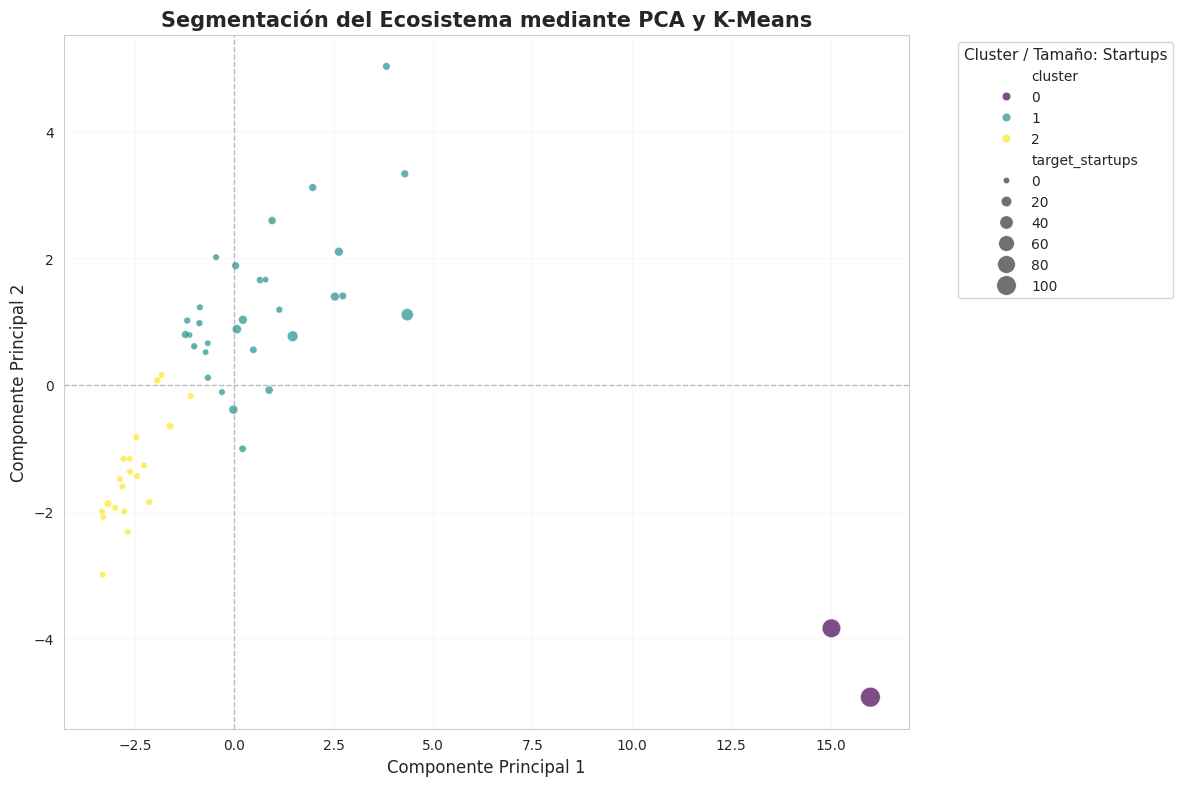

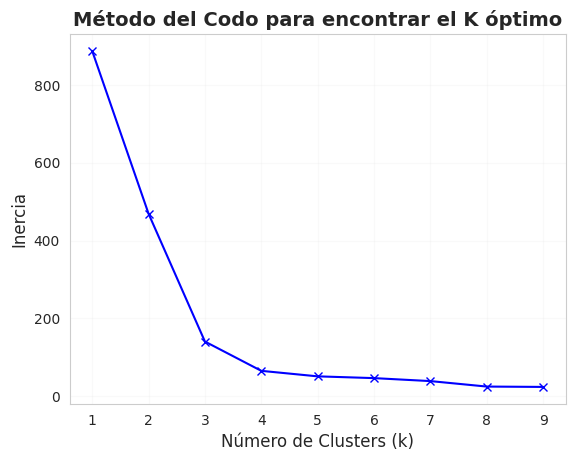

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df_pca = pd.DataFrame(data=componentes, columns=['PC1', 'PC2'])

# Crear un dataframe con los resultados del PCA y la variable objetivo
df_final = pd.DataFrame(data=componentes, columns=['PC1', 'PC2'], index=df['cpro'])
df_final['target_startups'] = df['startups'].values

# Ver la correlación de los componentes con las startups
print(df_final.corr()['target_startups'])

# 1. Calcular Clusters (K-Means) para dar sentido visual
# Elegimos 3 o 4 clusters como ejemplo
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_final['cluster'] = kmeans.fit_predict(componentes)

# 2. Mejorar la estética del gráfico
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Dibujar los puntos con colores por cluster y tamaño por 'target_startups'
scatter = sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='cluster', 
    size='target_startups',
    palette='viridis',
    alpha=0.7,
    data=df_final,
    sizes=(20, 200) # El tamaño varía según el éxito (startups)
)

# Añadir una línea de referencia en el origen
plt.axhline(0, color='grey', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', linewidth=1, alpha=0.5)

plt.title('Segmentación del Ecosistema mediante PCA y K-Means', fontsize=15)
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.legend(title='Cluster / Tamaño: Startups', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Calcular la inercia para diferentes números de clusters
inercias = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(componentes)
    inercias.append(kmeans.inertia_)

# Graficar el "Codo"
plt.plot(range(1, 10), inercias, 'bx-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para encontrar el K óptimo')
plt.show()

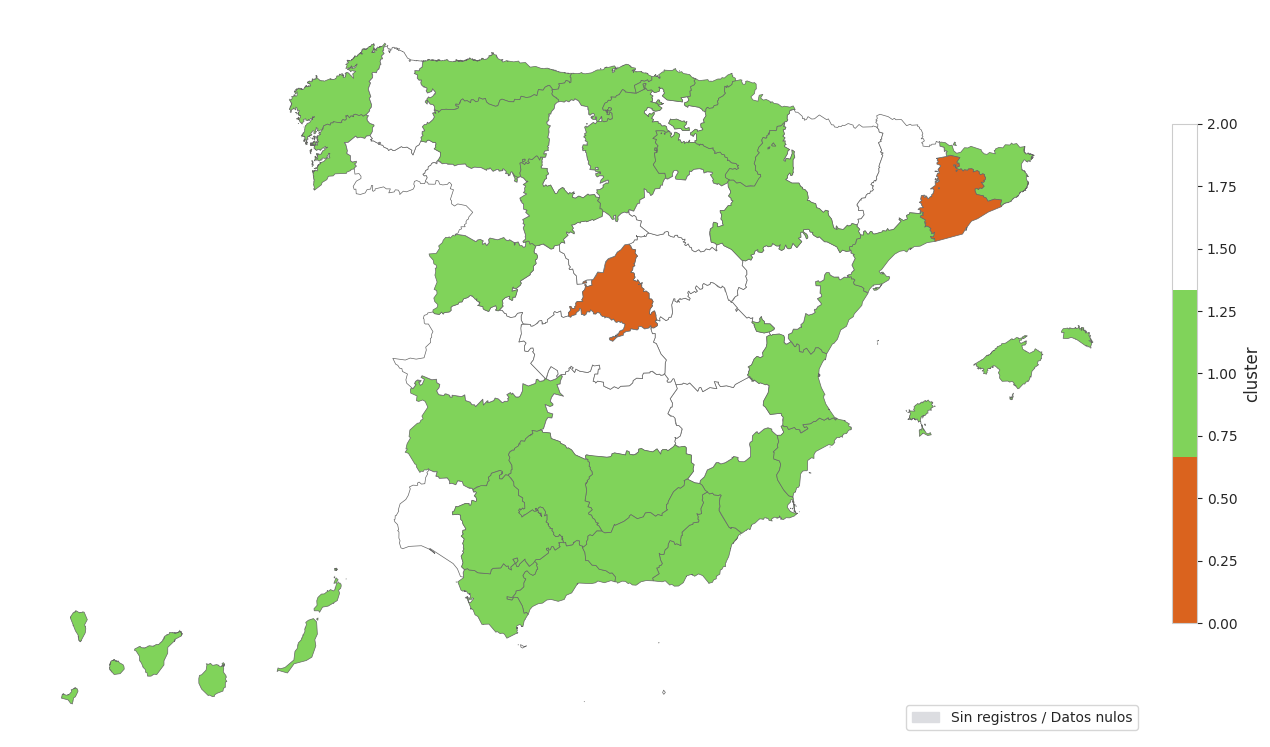

In [29]:
from src.analysis.visuals import generar_mapa
import geopandas as gpd
categoria_cluster_provincia = df_final.copy().reset_index()
categoria_cluster_provincia.to_csv('../data/gold/categoria_cluster_provincia_2023.csv', index=False)
cpro_provincias_dict = pd.read_csv("../data/silver/ine_ccaa_y_provincias.csv",dtype=str,sep=';').set_index('cpro')['provincia'].to_dict()
provincias_cluster_0 = categoria_cluster_provincia.query('cluster==0')['cpro'].map(cpro_provincias_dict)
provincias_cluster_1 = categoria_cluster_provincia.query('cluster==1')['cpro'].map(cpro_provincias_dict)
provincias_cluster_2 = categoria_cluster_provincia.query('cluster==2')['cpro'].map(cpro_provincias_dict)


url_geojson_provinces = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/spain-provinces.geojson"
gdf_provinces = gpd.read_file(url_geojson_provinces)
generar_mapa(gdf_provinces, categoria_cluster_provincia, 'cpro', 'cluster', custom_color_map={1: "#80d35a", 2: "#ffffff", 0: "#DA631E"})


In [30]:
# Ver la influencia de cada variable en los componentes
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=[
        'cobertura_5g_3_5ghz', 'cobertura_5g',
        'parques_cientificos', 'universidades_pub', 'universidades_priv',
        'aei_digital', 'aei_bio_salud', 'aei_industrial', 'aei_consumo',
        'icts_digital', 'icts_bio_salud', 'icts_industrial', 'icts_otro',
        'ct', 'cait',
        'somm_bio_salud', 'somm_ingenieria',
        'pct_egresados_stem', 'pct_master_stem', 'pct_doctorado_stem',
        'pct_afiliados_62', 'pct_afiliados_70', 'pct_afiliados_71', 'pct_afiliados_72', 'pct_afiliados_73',
    ]
)

# Ordenar por PC2 para ver qué lo define
print("PC1:")
print(loadings['PC1'].sort_values(ascending=False))
print("PC2:")
print(loadings['PC2'].sort_values(ascending=False))

PC1:
pct_afiliados_73       0.248705
somm_ingenieria        0.240631
pct_afiliados_62       0.240445
icts_industrial        0.234836
parques_cientificos    0.234404
icts_bio_salud         0.230813
pct_afiliados_70       0.228452
aei_digital            0.222864
universidades_priv     0.221740
aei_bio_salud          0.221627
somm_bio_salud         0.220951
icts_digital           0.219213
aei_industrial         0.213388
universidades_pub      0.211693
aei_consumo            0.207943
pct_afiliados_71       0.190412
cobertura_5g_3_5ghz    0.170571
pct_doctorado_stem     0.152710
pct_egresados_stem     0.152636
pct_master_stem        0.151565
pct_afiliados_72       0.150188
icts_otro              0.142922
cait                   0.136007
cobertura_5g           0.134939
ct                     0.117569
Name: PC1, dtype: float64
PC2:
pct_master_stem        0.398530
pct_egresados_stem     0.375491
pct_doctorado_stem     0.375315
ct                     0.305213
pct_afiliados_72       0.253308
cobe

In [31]:
df_final['poblacion'] = df['poblacion'].values
df_final['log_poblacion'] = np.log(df_final['poblacion'])
df_final['total_afiliados'] = df['total_afiliados'].values
df_final['log_afiliados'] = np.log(df_final['total_afiliados'])
df_final[['sinergia_bio_salud', 'sinergia_industrial', 'sinergia_digital']] = df[['sinergia_bio_salud', 'sinergia_industrial', 'sinergia_digital']].values

# Modelos de Regresión iniciales
- Binomial negativa
- Poisson

In [32]:

model_nb = smf.negativebinomial(formula='target_startups ~ PC1 + PC2', data=df_final, offset=df_final['log_poblacion']).fit()
print(model_nb.summary())


model_poisson = smf.poisson(formula='target_startups ~ PC1 + PC2', data=df_final, offset=df_final['log_poblacion']).fit()
print(model_poisson.summary())


model_nb_pc1 = smf.negativebinomial(formula='target_startups ~ PC1', data=df_final, offset=df_final['log_poblacion']).fit()
print(model_nb_pc1.summary())

model_poisson_pc1 = smf.poisson(formula='target_startups ~ PC1', data=df_final, offset=df_final['log_poblacion']).fit()
print(model_poisson_pc1.summary())

Optimization terminated successfully.
         Current function value: 2.045196
         Iterations: 13
         Function evaluations: 15
         Gradient evaluations: 15
                     NegativeBinomial Regression Results                      
Dep. Variable:        target_startups   No. Observations:                   52
Model:               NegativeBinomial   Df Residuals:                       49
Method:                           MLE   Df Model:                            2
Date:                Fri, 22 May 2026   Pseudo R-squ.:                 0.07650
Time:                        19:58:38   Log-Likelihood:                -106.35
converged:                       True   LL-Null:                       -115.16
Covariance Type:            nonrobust   LLR p-value:                 0.0001492
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -12.2010      0.102   -11

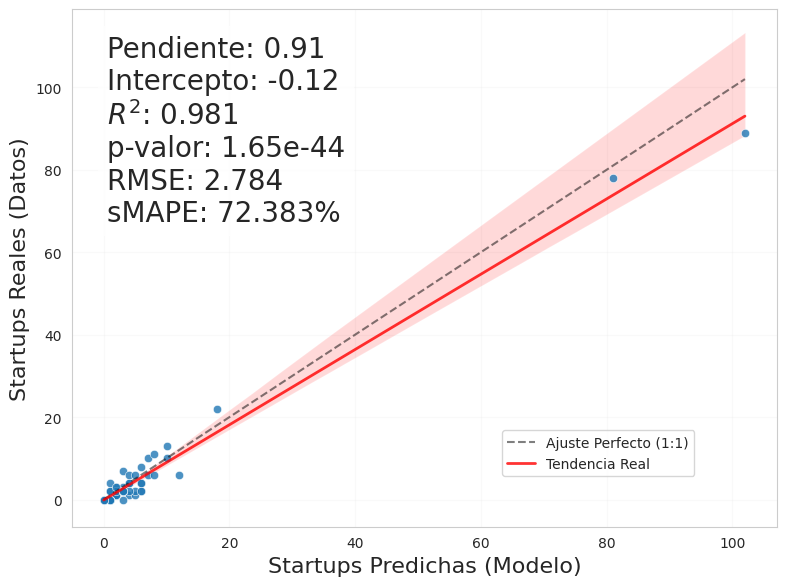

In [33]:
from scipy import stats
anno = 22 # dato para el título del gráfico
prediction = agg_22.copy() # dato para las predicciones

prediction[['PC1', 'PC2']] = pca.transform(scaler.transform(prediction[[
    'cobertura_5g_3_5ghz', 'cobertura_5g',
    'parques_cientificos', 'universidades_pub', 'universidades_priv',
    'aei_digital', 'aei_bio_salud', 'aei_industrial', 'aei_consumo',
    'icts_digital', 'icts_bio_salud', 'icts_industrial', 'icts_otro',
    'ct', 'cait',
    'somm_bio_salud', 'somm_ingenieria',
    'pct_egresados_stem', 'pct_master_stem', 'pct_doctorado_stem',
    'pct_afiliados_62', 'pct_afiliados_70', 'pct_afiliados_71', 'pct_afiliados_72', 'pct_afiliados_73',
]]))

# como PC2 tiene poca relevancia estadística usamos el modelo con solo PC1
X_mat = sm.add_constant(prediction[['PC1']])

# 2. Predecir TASA
tasa = model_poisson_pc1.predict(X_mat)

# 3. Escalar => tasa * población para obtener número de startups predichas
prediction['startups_predichas'] = tasa.values * prediction['poblacion'].astype(float).values
prediction['startups_predichas_redondeadas'] = prediction['startups_predichas'].round()

prediction['creadas_reales'] = prediction['startups']

plt.figure(figsize=(8, 6))

# 1. Dibujar la línea de "Perfección" (x = y) - ESTÁTICA
lims = [0, max(prediction['creadas_reales'].max(),prediction['startups_predichas_redondeadas'].max())]
plt.plot(lims, lims, '--k', alpha=0.5, label='Ajuste Perfecto (1:1)')

# EXTRA: Calcular la pendiente real para el TFG
slope, intercept, r_value, p_value, std_err = stats.linregress(
    prediction['startups_predichas_redondeadas'],
    prediction['creadas_reales']
)
RMSE = np.sqrt(np.mean((prediction['creadas_reales'] - prediction['startups_predichas_redondeadas']) ** 2))
sMAPE = np.mean(2 * np.abs(prediction['creadas_reales'] - prediction['startups_predichas_redondeadas']) / (np.abs(prediction['creadas_reales']) + np.abs(prediction['startups_predichas_redondeadas']))) * 100

texto_estadistico = (f"Pendiente: {slope:.2f}\n"
                     f"Intercepto: {intercept:.2f}\n"
                     f"$R^2$: {r_value**2:.3f}\n"
                     f"p-valor: {p_value:.2e}\n"
                     f"RMSE: {RMSE:.3f}\n"
                     f"sMAPE: {sMAPE:.3f}%"
                     )


# 2. Dibujar la LÍNEA DE CORRELACIÓN REAL (Tendencia empírica)
sns.regplot(
    data=prediction,
    x='startups_predichas_redondeadas',
    y='creadas_reales',
    scatter=False,
    color='red',
    label='Tendencia Real',
    line_kws={"linewidth": 2, "alpha": 0.8}
)

plt.text(0.05, 0.95, texto_estadistico, transform=plt.gca().transAxes,fontsize=20, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 3. graficar dispersión predichas(X) vs reales(Y)
sns.scatterplot(
    data=prediction,
    x='startups_predichas_redondeadas',
    y='creadas_reales',
    # size='total_afiliados',
    #hue='creadas_reales',
    sizes=(40, 400),
    alpha=0.8,
    #palette='viridis'
)



plt.xlabel('Startups Predichas (Modelo)', fontsize=16)
plt.ylabel('Startups Reales (Datos)', fontsize=16)
plt.legend(bbox_to_anchor=(0.6, 0.2), loc='upper left')
plt.tight_layout()

plt.show()

Evaluación por estratos modelo inicial

In [34]:
print(agg_23['startups'].describe(),'\n')
cpro_25 = agg_23.query('startups <= 1')['cpro'].tolist()
cpro_iqr = agg_23.query('startups > 1 and startups < 6')['cpro'].tolist()
cpro_75 = agg_23.query('startups >= 6')['cpro'].tolist()
print(agg_23.query('startups >= 6')['startups'].describe())
cpro_75_iqr = agg_23.query('startups >= 6 and startups <= 17')['cpro'].tolist()
cpro_75_75 = agg_23.query('startups > 17')['cpro'].tolist()
print("Provincias con 0-1 startups:", len(cpro_25))
print("Provincias con 2-5 startups:", len(cpro_iqr))
print("Provincias con 6+ startups:", len(cpro_75_iqr))
print("Provincias con 17+ startups:", len(cpro_75_75), cpro_75_75)

mad_bcn_val_mlg = ['08', '28', '46', '29']

count     52.000000
mean       7.711538
std       18.905686
min        0.000000
25%        1.000000
50%        2.000000
75%        6.000000
max      103.000000
Name: startups, dtype: float64 

count     15.000000
mean      22.933333
std       30.776769
min        6.000000
25%        6.500000
50%       11.000000
75%       17.500000
max      103.000000
Name: startups, dtype: float64
Provincias con 0-1 startups: 22
Provincias con 2-5 startups: 15
Provincias con 6+ startups: 11
Provincias con 17+ startups: 4 ['08', '28', '29', '46']


In [35]:
prediction_23 = agg_23.copy()
prediction_23[['PC1', 'PC2']] = pca.transform(scaler.transform(prediction_23[[
    'cobertura_5g_3_5ghz', 'cobertura_5g',
    'parques_cientificos', 'universidades_pub', 'universidades_priv',
    'aei_digital', 'aei_bio_salud', 'aei_industrial', 'aei_consumo',
    'icts_digital', 'icts_bio_salud', 'icts_industrial', 'icts_otro',
    'ct', 'cait',
    'somm_bio_salud', 'somm_ingenieria',
    'pct_egresados_stem', 'pct_master_stem', 'pct_doctorado_stem',
    'pct_afiliados_62', 'pct_afiliados_70', 'pct_afiliados_71', 'pct_afiliados_72', 'pct_afiliados_73',
]]))
tasa = model_poisson_pc1.predict(X_mat)
prediction_23['startups_predichas'] = tasa.values * prediction_23['poblacion'].astype(float).values
prediction_23['startups_predichas_redondeadas'] = prediction_23['startups_predichas'].round()
prediction_23['startups_reales'] = prediction_23['startups']

data = []

for stratum, label in [(cpro_25, "Q1"), (cpro_iqr, "IQR"), (cpro_75, "Q4"), (mad_bcn_val_mlg, "Top 4")]:
    true_values_stratum = prediction_23.query('cpro in @stratum')['startups_reales']
    pred_values_stratum = prediction_23.query('cpro in @stratum')['startups_predichas_redondeadas']
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        pred_values_stratum,
        true_values_stratum
    )
    RMSE = np.sqrt(np.mean((true_values_stratum - pred_values_stratum) ** 2))
    sMAPE = np.mean(2 * np.abs(true_values_stratum - pred_values_stratum) / (np.abs(true_values_stratum) + np.abs(pred_values_stratum))) * 100
    data.append({
        'Estrato': label,
        'Pendiente': f"{slope:.2f}",
        'Intercepto': f"{intercept:.2f}",
        'R^2': f"{r_value**2:.3f}",
        'p-valor': f"{p_value:.2e}",
        'RMSE': f"{RMSE:.3f}",
        'sMAPE': f"{sMAPE:.3f}%"
    })
results_df = pd.DataFrame(data)
print(results_df.to_latex(index=False))

\begin{tabular}{lllllll}
\toprule
Estrato & Pendiente & Intercepto & R^2 & p-valor & RMSE & sMAPE \\
\midrule
Q1 & 0.11 & 0.31 & 0.088 & 1.80e-01 & 1.834 & 115.810% \\
IQR & 0.45 & 1.57 & 0.419 & 9.08e-03 & 1.265 & 42.059% \\
Q4 & 1.00 & 3.59 & 0.977 & 4.78e-12 & 5.762 & 33.376% \\
Top 4 & 0.87 & 15.16 & 0.995 & 2.43e-03 & 10.062 & 35.317% \\
\bottomrule
\end{tabular}



# PCA y modelo alternativo

In [36]:
prediction_23 = agg_23.copy()
pca_2 = PCA(n_components=2)
scaler_2 = StandardScaler()
prediction_23[['PC1', 'PC2']] = pca_2.fit_transform(scaler_2.fit_transform(prediction_23[[
    # 'cobertura_5g_3_5ghz',
    'cobertura_5g',
    # 'pct_afiliados_62',
    'pct_reg_cta_propia_62', 'pct_reg_cta_ajena_62',
    # 'pct_afiliados_70',
    'pct_reg_cta_propia_70',  # 'pct_reg_cta_ajena_70',
    'pct_afiliados_71',
    # 'pct_reg_cta_propia_71',
    # 'pct_reg_cta_ajena_71',
    'pct_afiliados_72',
    # 'pct_reg_cta_propia_72',
    # 'pct_reg_cta_ajena_72',
    'pct_reg_cta_propia_73',
    # 'pct_reg_cta_ajena_73'
]]))
model_poisson_2 = smf.poisson(formula='startups ~ PC1 + PC2',
                              data=prediction_23, offset=np.log(prediction_23['poblacion'])).fit()
summary_2 = model_poisson_2.summary()
# model_poisson_pc1_2 = smf.poisson(formula='startups ~ PC1', data=prediction_21, offset=np.log(prediction_21['poblacion'])).fit()
# summary_pc1_2 = model_poisson_pc1_2.summary()
print(summary_2)
# print(summary_pc1_2)
X_mat = sm.add_constant(prediction_23[['PC1', 'PC2']])
tasa = model_poisson_2.predict(X_mat)
prediction_23['startups_predichas'] = tasa.values * \
    prediction_23['poblacion'].astype(float).values
prediction_23['startups_predichas_redondeadas'] = prediction_23['startups_predichas'].round()
prediction_23['startups_reales'] = prediction_23['startups']

data = []

for stratum, label in [(cpro_25, "Primer Cuartil"), (cpro_iqr, "Rango Intercuartílico"), (cpro_75, "Tercer Cuartil"), (mad_bcn_val_mlg, "Top 4 Provincias")]:
    true_values_stratum = prediction_23.query(
        'cpro in @stratum')['startups_reales']
    pred_values_stratum = prediction_23.query(
        'cpro in @stratum')['startups_predichas_redondeadas']
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        pred_values_stratum,
        true_values_stratum
    )
    RMSE = np.sqrt(np.mean((true_values_stratum - pred_values_stratum) ** 2))
    sMAPE = np.mean(2 * np.abs(true_values_stratum - pred_values_stratum) /
                    (np.abs(true_values_stratum) + np.abs(pred_values_stratum))) * 100
    data.append({
        'Estrato': label,
        'Pendiente': f"{slope:.2f}",
        'Intercepto': f"{intercept:.2f}",
        'R^2': f"{r_value**2:.3f}",
        'p-valor': f"{p_value:.2e}",
        'RMSE': f"{RMSE:.3f}",
        'sMAPE': f"{sMAPE:.3f}%"
    })
results_df = pd.DataFrame(data)
print(results_df.to_latex(index=False))

data_predicciones_top = []
data_predicciones = []
# rendimiento predicciones 2021, 2022 y 2024:
for agg, label in [(agg_21, "2021"), (agg_22, "2022"), (agg_23, "2023"), (agg_24, "2024")]:
    prediction = agg.copy()
    prediction[['PC1', 'PC2']] = pca_2.transform(scaler_2.transform(prediction[[
        # 'cobertura_5g_3_5ghz',
        'cobertura_5g',
        # 'pct_afiliados_62',
        'pct_reg_cta_propia_62', 'pct_reg_cta_ajena_62',
        # 'pct_afiliados_70',
        'pct_reg_cta_propia_70',  # 'pct_reg_cta_ajena_70',
        'pct_afiliados_71',
        # 'pct_reg_cta_propia_71',
        # 'pct_reg_cta_ajena_71',
        'pct_afiliados_72',
        # 'pct_reg_cta_propia_72',
        # 'pct_reg_cta_ajena_72',
        'pct_reg_cta_propia_73',
        # 'pct_reg_cta_ajena_73'
    ]]))
    X_mat = sm.add_constant(prediction[['PC1', 'PC2']])
    tasa = model_poisson_2.predict(X_mat)
    prediction['startups_predichas'] = tasa.values * \
        prediction['poblacion'].astype(float).values
    prediction['startups_predichas_redondeadas'] = prediction['startups_predichas'].round()
    prediction['startups_reales'] = prediction['startups']
    data = []
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        prediction.query(
            'cpro in @mad_bcn_val_mlg')['startups_predichas_redondeadas'],
        prediction.query('cpro in @mad_bcn_val_mlg')['startups_reales']
    )
    RMSE = np.sqrt(np.mean(
        (prediction.query('cpro in @mad_bcn_val_mlg')['startups_reales'] - prediction.query('cpro in @mad_bcn_val_mlg')['startups_predichas_redondeadas']) ** 2))
    sMAPE = np.mean(2 * np.abs(prediction.query('cpro in @mad_bcn_val_mlg')['startups_reales'] - prediction.query('cpro in @mad_bcn_val_mlg')['startups_predichas_redondeadas']) / (
        np.abs(prediction.query('cpro in @mad_bcn_val_mlg')['startups_reales']) + np.abs(prediction.query('cpro in @mad_bcn_val_mlg')['startups_predichas_redondeadas']))) * 100
    data_predicciones_top.append({
        'Año': label,
        'Estrato': 'Top 4 Provincias',
        'Pendiente': f"{slope:.2f}",
        'Intercepto': f"{intercept:.2f}",
        'R^2': f"{r_value**2:.3f}",
        'p-valor': f"{p_value:.2e}",
        'RMSE': f"{RMSE:.3f}",
        'sMAPE': f"{sMAPE:.3f}%"
    })
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        prediction['startups_predichas_redondeadas'],
        prediction['startups_reales']
    )
    RMSE = np.sqrt(np.mean(
        (prediction['startups_reales'] - prediction['startups_predichas_redondeadas']) ** 2))
    sMAPE = np.mean(2 * np.abs(prediction['startups_reales'] - prediction['startups_predichas_redondeadas']) / (
        np.abs(prediction['startups_reales']) + np.abs(prediction['startups_predichas_redondeadas']))) * 100
    data_predicciones.append({
        'Año': label,
        'Estrato': 'Total',
        'Pendiente': f"{slope:.2f}",
        'Intercepto': f"{intercept:.2f}",
        'R^2': f"{r_value**2:.3f}",
        'p-valor': f"{p_value:.2e}",
        'RMSE': f"{RMSE:.3f}",
        'sMAPE': f"{sMAPE:.3f}%"
    })

results_df = pd.DataFrame(data_predicciones_top)
print(results_df.to_latex(index=False))
results_df = pd.DataFrame(data_predicciones)
print(results_df.to_latex(index=False))

Optimization terminated successfully.
         Current function value: 1.886117
         Iterations 6
                          Poisson Regression Results                          
Dep. Variable:               startups   No. Observations:                   52
Model:                        Poisson   Df Residuals:                       49
Method:                           MLE   Df Model:                            2
Date:                Fri, 22 May 2026   Pseudo R-squ.:                  0.3836
Time:                        19:58:38   Log-Likelihood:                -98.078
converged:                       True   LL-Null:                       -159.11
Covariance Type:            nonrobust   LLR p-value:                 3.118e-27
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -12.3016      0.088   -140.405      0.000     -12.473     -12.130
PC1            0.2075      0.

Cluster nuevo con PCA

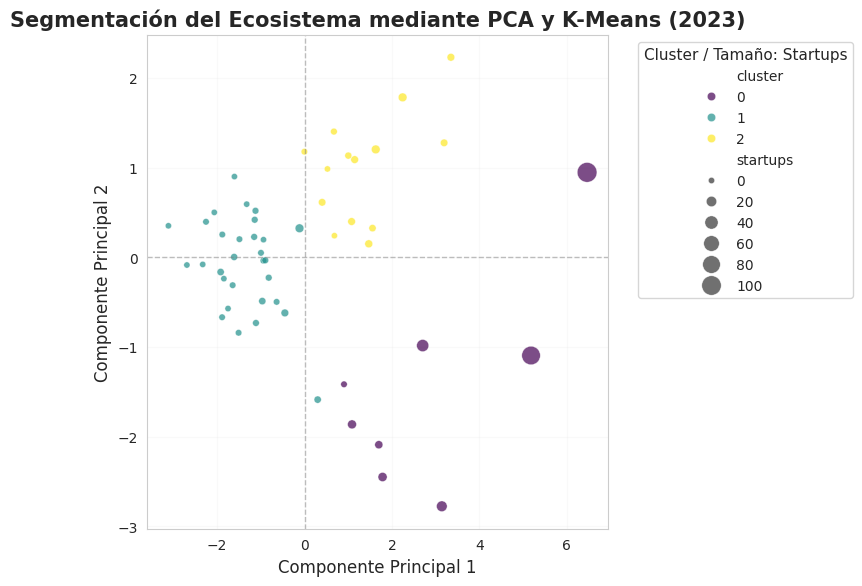

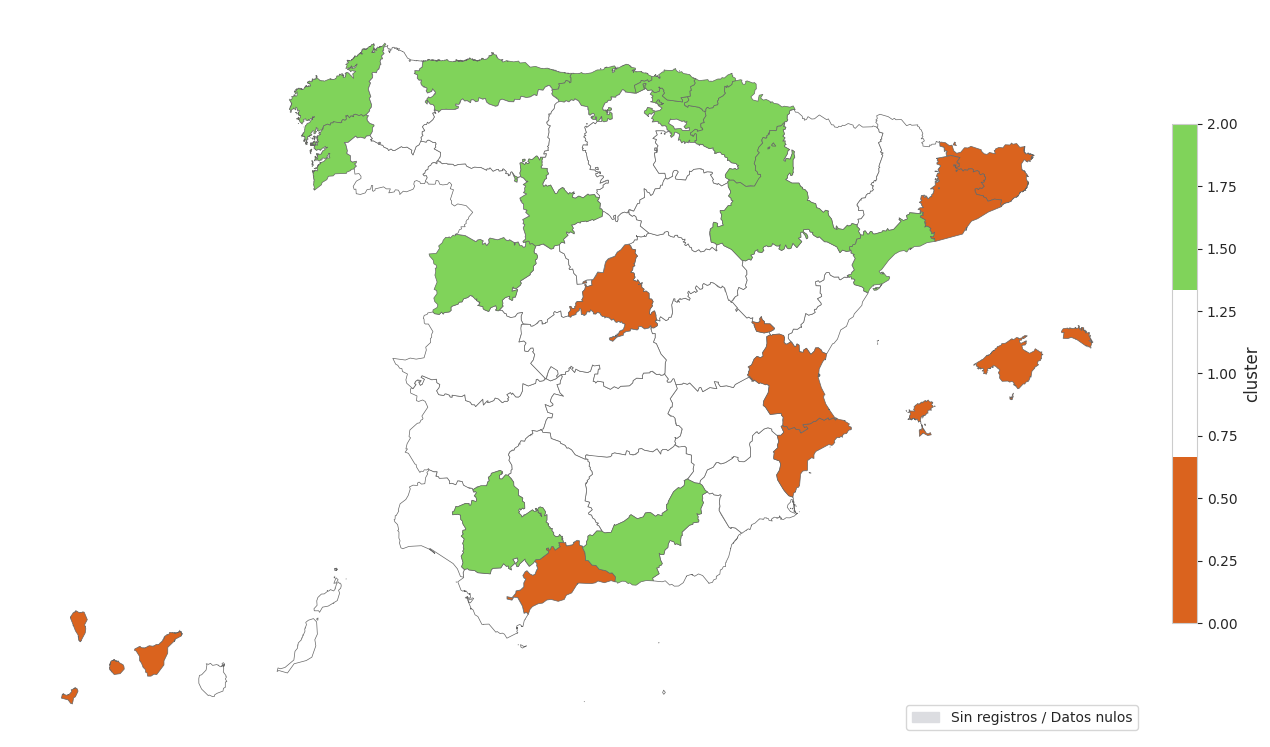

In [38]:
#cluster nuevo
componentes = prediction_23[['startups','PC1','PC2']].copy()

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
componentes['cluster'] = kmeans.fit_predict(componentes[['PC1', 'PC2']])
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")
scatter = sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='cluster',
    size='startups',
    palette='viridis',
    alpha=0.7,
    data=componentes,
    sizes=(20, 200)
)
plt.axhline(0, color='grey', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', linewidth=1, alpha=0.5)
plt.title('Segmentación del Ecosistema mediante PCA y K-Means (2023)', fontsize=15)
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.legend(title='Cluster / Tamaño: Startups', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

componentes['cpro'] = prediction_23['cpro'].values
url_geojson_provinces = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/spain-provinces.geojson"
gdf_provinces = gpd.read_file(url_geojson_provinces)
generar_mapa(gdf_provinces, componentes, 'cpro', 'cluster', custom_color_map={2: "#80d35a", 1: "#ffffff", 0: "#DA631E"})



Evolución de empresas creadas en las top 4 provincias

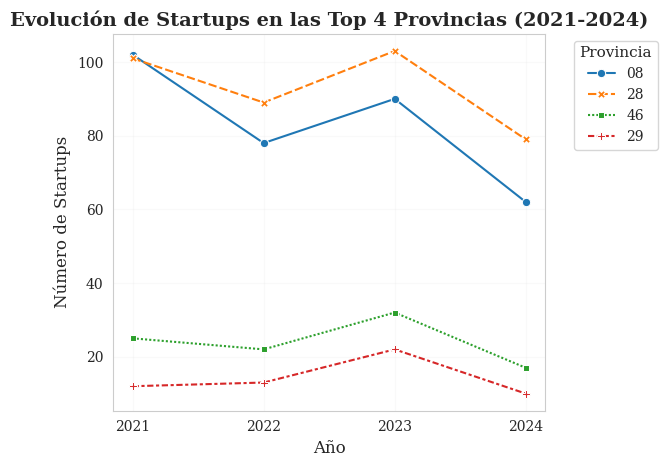

In [ ]:
nuevas_empresas_provinciales_2021.query('cpro in @mad_bcn_val_mlg')

evo_2021_2024 = pd.DataFrame({'cpro': mad_bcn_val_mlg})
evo_2021_2024['2021'] = evo_2021_2024.cpro.map(nuevas_empresas_provinciales_2021.query('cpro in @mad_bcn_val_mlg').set_index('cpro')['startups'])
evo_2021_2024['2022'] = evo_2021_2024.cpro.map(nuevas_empresas_provinciales_2022.query('cpro in @mad_bcn_val_mlg').set_index('cpro')['startups'])
evo_2021_2024['2023'] = evo_2021_2024.cpro.map(nuevas_empresas_provinciales_2023.query('cpro in @mad_bcn_val_mlg').set_index('cpro')['startups'])
evo_2021_2024['2024'] = evo_2021_2024.cpro.map(nuevas_empresas_provinciales_2024.query('cpro in @mad_bcn_val_mlg').set_index('cpro')['startups'])

sns.lineplot(data=evo_2021_2024.set_index('cpro').T, markers=True)
plt.title('Evolución de Startups en las Top 4 Provincias (2021-2024)', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Número de Startups', fontsize=12)
plt.legend(title='Provincia', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()